In [13]:
import pandas as pd
import numpy as np
import re
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # Or ['Microsoft YaHei'] Microsoft YaHei etc.
plt.rcParams['axes.unicode_minus'] = False   # Solve the issue where '-' displays as a square

# Load data
df = pd.read_excel('Data_Merged_with_SMILES.xlsx')
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(df.head(3))

Dataset shape: (1573, 18)

Column names: ['Voc', 'Jsc', 'FF', 'PCE', 'HOMO_A', 'LUMO_A', 'EgCV_A', 'λ_A_absorption', 'EgA_opt', 'HOMO_D', 'LUMO_D', 'EgCV_D', 'λ_D_absorption', 'EgD_opt', 'Acceptor', 'SMILES_acc', 'Donor', 'SMILES_don']

First 3 rows:
    Voc   Jsc     FF   PCE  HOMO_A  LUMO_A  EgCV_A  λ_A_absorption  EgA_opt  \
0  0.91  6.32  32.85  1.89   -5.69   -4.11    1.58           800.0     1.55   
1  0.91  6.84  33.22  2.08   -5.69   -4.11    1.58           800.0     1.55   
2  0.89  6.21  66.09  3.65   -5.69   -4.11    1.58           800.0     1.55   

   HOMO_D  LUMO_D  EgCV_D  λ_D_absorption  EgD_opt Acceptor  \
0   -5.43   -3.37    2.06           625.0     1.98     ITIC   
1   -5.43   -3.37    2.06           625.0     1.98     ITIC   
2   -5.42   -3.40    2.02           635.0     1.95     ITIC   

                                          SMILES_acc   Donor  \
0  CCCCCCc%15ccc(C%14(c1ccc(CCCCCC)cc1)Cc9cc8/C5=...     3MT   
1  CCCCCCc%15ccc(C%14(c1ccc(CCCCCC)cc1)Cc9cc8/C5=..

In [14]:
class FunctionalGroupAnalyzer:
    """
    Functional group analyzer based on SMILES string pattern matching
    Used for causal inference analysis of organic solar cell acceptor molecules
    """

    def __init__(self):
        # Define SMILES patterns for key functional groups
        self.functional_groups = {
            # Electron-withdrawing groups (affect LUMO)
            'cyano': {'pattern': r'C#N', 'type': 'electron_withdrawing', 'effect': 'lower_LUMO'},
            'fluorine': {'pattern': r'\(F\)|cF|F\)', 'type': 'electron_withdrawing', 'effect': 'lower_LUMO'},
            'chlorine': {'pattern': r'\(Cl\)|cCl|Cl\)', 'type': 'electron_withdrawing', 'effect': 'lower_LUMO'},
            'carbonyl': {'pattern': r'C\(=O\)|=O', 'type': 'electron_withdrawing', 'effect': 'lower_LUMO'},

            # Electron-donating groups (affect HOMO)
            'alkyl_chain': {'pattern': r'CCCC|CCCCC|CCCCCC|CCCCCCC|C\d{4,}', 'type': 'electron_donating', 'effect': 'raise_HOMO'},
            'alkoxy': {'pattern': r'OC|OCC', 'type': 'electron_donating', 'effect': 'raise_HOMO'},
            'thiophene': {'pattern': r'sc|cs', 'type': 'electron_donating', 'effect': 'raise_HOMO'},

            # Conjugated structure features
            'conjugated_bridge': {'pattern': r'/C=C|C=C|/C=C\\', 'type': 'conjugation', 'effect': 'reduce_bandgap'},
            'aromatic_ring': {'pattern': r'c\d|c\%', 'type': 'aromatic', 'effect': 'stabilize'},

            # Heterocyclic features
            'benzothiadiazole': {'pattern': r'nsnc|NSN', 'type': 'acceptor_core', 'effect': 'strong_accepting'},
            'indacene': {'pattern': r'c\d+sc|c\d+cc\d+sc', 'type': 'fused_ring', 'effect': 'broad_absorption'},

            # Special structures
            'spiro': {'pattern': r'C\d+\([^)]+\)c', 'type': '3D_structure', 'effect': 'morphology'},
            'ladder_type': {'pattern': r'sc\d+c\d+sc', 'type': 'rigid_core', 'effect': 'high_mobility'},
        }

        # Acceptor core type classification
        self.acceptor_cores = {
            'ITIC_family': ['ITIC', 'IT-4F', 'ITIC-Th', 'ITIC1', 'ITIC2', 'm-ITIC'],
            'Y6_family': ['Y6', 'Y6-BO', 'Y6-2O', 'N3', 'L8-BO', 'L8-BO+', 'BTP-eC9', 'BTP-eC9-4F'],
            'IDIC_family': ['IDIC', 'IDIC-4F', 'IDIC8-F', 'IDIC8-H', 'IDIC8-M'],
            'Fused_ring': ['F-2Cl', 'F-1Cl', 'F-0Cl', 'F5IC', 'F7IC', 'F9IC'],
            'Other': []
        }

    def extract_functional_groups(self, smiles):
        """Extract functional groups from SMILES"""
        if pd.isna(smiles):
            return {}

        detected = {}
        for fg_name, fg_info in self.functional_groups.items():
            matches = re.findall(fg_info['pattern'], smiles, re.IGNORECASE)
            count = len(matches)
            if count > 0:
                detected[fg_name] = {
                    'count': count,
                    'type': fg_info['type'],
                    'effect': fg_info['effect']
                }
        return detected

    def classify_acceptor_core(self, acceptor_name):
        """Classify acceptor core type based on name"""
        for core_type, members in self.acceptor_cores.items():
            if any(member in str(acceptor_name) for member in members):
                return core_type
        return 'Other'

    def calculate_conjugation_length(self, smiles):
        """Estimate conjugation length (based on the number of consecutive conjugated structures)"""
        if pd.isna(smiles):
            return 0
        # Calculate the number of conjugated double bonds/aromatic rings
        conjugated_units = len(re.findall(r'/C=C|C=C|c\d+cc\d+', smiles))
        return conjugated_units

    def get_molecular_features(self, row):
        """Extract all features for a single molecule"""
        smiles = row['SMILES_acc']
        acceptor_name = row['Acceptor']

        # Basic functional group analysis
        fg_dict = self.extract_functional_groups(smiles)

        # Core type
        core_type = self.classify_acceptor_core(acceptor_name)

        # Conjugation length
        conj_length = self.calculate_conjugation_length(smiles)

        # Count key groups
        fg_summary = {
            'n_cyano': fg_dict.get('cyano', {}).get('count', 0),
            'n_fluorine': fg_dict.get('fluorine', {}).get('count', 0),
            'n_chlorine': fg_dict.get('chlorine', {}).get('count', 0),
            'n_carbonyl': fg_dict.get('carbonyl', {}).get('count', 0),
            'n_alkyl': fg_dict.get('alkyl_chain', {}).get('count', 0),
            'n_thiophene': fg_dict.get('thiophene', {}).get('count', 0),
            'has_benzothiadiazole': 1 if 'benzothiadiazole' in fg_dict else 0,
            'has_indacene': 1 if 'indacene' in fg_dict else 0,
            'conjugation_length': conj_length,
            'core_type': core_type,
            'electron_withdrawing_score': sum([fg_dict.get(k, {}).get('count', 0)
                                               for k in ['cyano', 'fluorine', 'chlorine', 'carbonyl']]),
            'electron_donating_score': sum([fg_dict.get(k, {}).get('count', 0)
                                            for k in ['alkyl_chain', 'alkoxy', 'thiophene']]),
        }

        return fg_summary

# Initialize analyzer
analyzer = FunctionalGroupAnalyzer()

# Apply analysis to dataset
print("Analyzing acceptor molecule functional groups...")
features_list = []
for idx, row in df.iterrows():
    if idx % 100 == 0:
        print(f"Processed {idx}/{len(df)} molecules")
    features = analyzer.get_molecular_features(row)
    features['index'] = idx
    features['Acceptor'] = row['Acceptor']
    features['PCE'] = row['PCE']
    features['HOMO_A'] = row['HOMO_A']
    features['LUMO_A'] = row['LUMO_A']
    features['EgCV_A'] = row['EgCV_A']
    features_list.append(features)

# Create feature DataFrame
features_df = pd.DataFrame(features_list)
print(f"\nFeature extraction complete! Total {len(features_df)} molecules")
print(f"\nCore type distribution:")
print(features_df['core_type'].value_counts())

Analyzing acceptor molecule functional groups...
Processed 0/1573 molecules
Processed 100/1573 molecules
Processed 200/1573 molecules
Processed 300/1573 molecules
Processed 400/1573 molecules
Processed 500/1573 molecules
Processed 600/1573 molecules
Processed 700/1573 molecules
Processed 800/1573 molecules
Processed 900/1573 molecules
Processed 1000/1573 molecules
Processed 1100/1573 molecules
Processed 1200/1573 molecules
Processed 1300/1573 molecules
Processed 1400/1573 molecules
Processed 1500/1573 molecules

Feature extraction complete! Total 1573 molecules

Core type distribution:
core_type
Other          908
Y6_family      405
ITIC_family    216
IDIC_family     34
Fused_ring      10
Name: count, dtype: int64


In [15]:
# Create grouping strategy based on functional groups
class CausalGroupingAnalysis:
    """
    Grouping analysis based on causal inference ideas
    Goal: Identify causal effects of different functional groups on electronic properties
    """

    def __init__(self, features_df):
        self.df = features_df
        self.groups = {}

    def group_by_halogen_substitution(self):
        """
        Strategy 1: Group by halogen substituents
        Test hypothesis: Causal effect of F/Cl substitution on LUMO energy level
        """
        df = self.df.copy()

        # Define halogen substitution categories
        def classify_halogen(row):
            f_count = row['n_fluorine']
            cl_count = row['n_chlorine']

            if f_count == 0 and cl_count == 0:
                return 'no_halogen'
            elif f_count > 0 and cl_count == 0:
                return 'fluorine_only'
            elif f_count == 0 and cl_count > 0:
                return 'chlorine_only'
            else:
                return 'mixed_halogen'

        df['halogen_group'] = df.apply(classify_halogen, axis=1)

        # Calculate statistical features for each group
        summary = df.groupby('halogen_group').agg({
            'LUMO_A': ['mean', 'std', 'count'],
            'HOMO_A': ['mean', 'std'],
            'EgCV_A': ['mean', 'std'],
            'PCE': ['mean', 'std', 'max']
        }).round(3)

        self.groups['halogen'] = df
        return summary

    def group_by_cyano_groups(self):
        """
        Strategy 2: Group by cyano group count
        Test hypothesis: Causal effect of cyano group count on bandgap
        """
        df = self.df.copy()

        # Cyano groups usually appear in pairs (end groups)
        df['cyano_group'] = pd.cut(df['n_cyano'],
                                   bins=[-1, 0, 2, 4, 10],
                                   labels=['no_cyano', 'low_cyano', 'medium_cyano', 'high_cyano'])

        summary = df.groupby('cyano_group').agg({
            'LUMO_A': ['mean', 'std', 'count'],
            'EgCV_A': ['mean', 'std'],
            'PCE': ['mean', 'std']
        }).round(3)

        self.groups['cyano'] = df
        return summary

    def group_by_core_conjugation(self):
        """
        Strategy 3: Group by core type and conjugation length
        Test hypothesis: Causal effect of conjugation length on absorption wavelength
        """
        df = self.df.copy()

        # Conjugation length classification
        df['conj_category'] = pd.cut(df['conjugation_length'],
                                     bins=[0, 10, 20, 30, 100],
                                     labels=['short', 'medium', 'long', 'very_long'])

        # Core-Conjugation combination
        df['core_conj_group'] = df['core_type'] + '_' + df['conj_category'].astype(str)

        summary = df.groupby(['core_type', 'conj_category']).agg({
            'EgCV_A': ['mean', 'std', 'count'],
            'PCE': ['mean', 'std', 'max'],
            'HOMO_A': ['mean', 'std']
        }).round(3)

        self.groups['core_conjugation'] = df
        return summary

    def group_by_electron_withdrawing_strength(self):
        """
        Strategy 4: Group by electron-withdrawing ability composite score
        Test hypothesis: Causal effect of electron-withdrawing strength on energy levels
        """
        df = self.df.copy()

        # Calculate electron-withdrawing strength score
        df['ewg_score'] = (df['n_cyano'] * 2 +
                           df['n_fluorine'] * 1.5 +
                           df['n_chlorine'] * 1.2 +
                           df['n_carbonyl'] * 1.0)

        df['ewg_category'] = pd.cut(df['ewg_score'],
                                    bins=[-1, 2, 5, 8, 20],
                                    labels=['weak_EWG', 'moderate_EWG', 'strong_EWG', 'very_strong_EWG'])

        summary = df.groupby('ewg_category').agg({
            'LUMO_A': ['mean', 'std', 'count'],
            'HOMO_A': ['mean', 'std'],
            'EgCV_A': ['mean', 'std'],
            'PCE': ['mean', 'std', 'max']
        }).round(3)

        self.groups['ewg'] = df
        return summary

    def generate_counterfactual_pairs(self):
        """
        Generate counterfactual analysis pairs
        Example: Molecule pairs with same core, different halogen substitution
        """
        df = self.df.copy()

        # Find molecules of the same core type
        counterfactuals = []

        for core in df['core_type'].unique():
            if core == 'Other':
                continue

            core_data = df[df['core_type'] == core]

            # Compare effects of different halogen substitutions
            no_hal = core_data[core_data['n_fluorine'] + core_data['n_chlorine'] == 0]
            with_hal = core_data[core_data['n_fluorine'] + core_data['n_chlorine'] > 0]

            if len(no_hal) > 0 and len(with_hal) > 0:
                counterfactuals.append({
                    'core_type': core,
                    'no_halogen_LUMO': no_hal['LUMO_A'].mean(),
                    'with_halogen_LUMO': with_hal['LUMO_A'].mean(),
                    'LUMO_shift': with_hal['LUMO_A'].mean() - no_hal['LUMO_A'].mean(),
                    'no_halogen_PCE': no_hal['PCE'].mean(),
                    'with_halogen_PCE': with_hal['PCE'].mean(),
                    'PCE_improvement': with_hal['PCE'].mean() - no_hal['PCE'].mean()
                })

        return pd.DataFrame(counterfactuals)

# Execute grouping analysis
print("=" * 60)
print("Causal Inference Grouping Analysis Based on Functional Groups")
print("=" * 60)

causal_analysis = CausalGroupingAnalysis(features_df)

print("\n[Group 1] Halogen Substituent Effect Analysis")
print("-" * 40)
halogen_summary = causal_analysis.group_by_halogen_substitution()
print(halogen_summary)

print("\n[Group 2] Cyano Group Count Effect Analysis")
print("-" * 40)
cyano_summary = causal_analysis.group_by_cyano_groups()
print(cyano_summary)

print("\n[Group 3] Core Type and Conjugation Length Effect")
print("-" * 40)
core_summary = causal_analysis.group_by_core_conjugation()
print(core_summary.head(15))

print("\n[Group 4] Electron-Withdrawing Strength Composite Effect")
print("-" * 40)
ewg_summary = causal_analysis.group_by_electron_withdrawing_strength()
print(ewg_summary)

Causal Inference Grouping Analysis Based on Functional Groups

[Group 1] Halogen Substituent Effect Analysis
----------------------------------------
              LUMO_A              HOMO_A        EgCV_A            PCE         \
                mean    std count   mean    std   mean    std    mean    std   
halogen_group                                                                  
chlorine_only -3.948  0.122   216 -5.630  0.116  1.682  0.145  14.604  4.112   
fluorine_only -3.953  0.132   864 -5.633  0.115  1.677  0.158  13.772  4.489   
mixed_halogen -3.917  0.092    26 -5.627  0.112  1.710  0.164  15.574  3.171   
no_halogen    -3.888  0.160   467 -5.568  0.159  1.688  0.192   9.587  4.243   

                      
                 max  
halogen_group         
chlorine_only  19.79  
fluorine_only  20.80  
mixed_halogen  19.40  
no_halogen     20.32  

[Group 2] Cyano Group Count Effect Analysis
----------------------------------------
             LUMO_A              EgCV_A   

C:\Users\21472\AppData\Local\Temp\ipykernel_67688\283946618.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby('cyano_group').agg({
C:\Users\21472\AppData\Local\Temp\ipykernel_67688\283946618.py:82: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby(['core_type', 'conj_category']).agg({
C:\Users\21472\AppData\Local\Temp\ipykernel_67688\283946618.py:108: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence


[Counterfactual Analysis] Effect Comparison: Same Core, Different Halogen Substituents
     core_type  no_halogen_LUMO  with_halogen_LUMO  LUMO_shift  \
0  ITIC_family         -3.91368          -4.019670   -0.105990   
1   Fused_ring         -3.71000          -3.903333   -0.193333   
2  IDIC_family         -3.92450          -3.922857    0.001643   

   no_halogen_PCE  with_halogen_PCE  PCE_improvement  
0          9.1068         10.292527         1.185727  
1          5.4900          8.964444         3.474444  
2          9.0865          7.776429        -1.310071  


C:\Users\21472\AppData\Local\Temp\ipykernel_67688\1202765687.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(pce_by_core, labels=core_types, patch_artist=True)



Save as: functional_group_causal_analysis.png


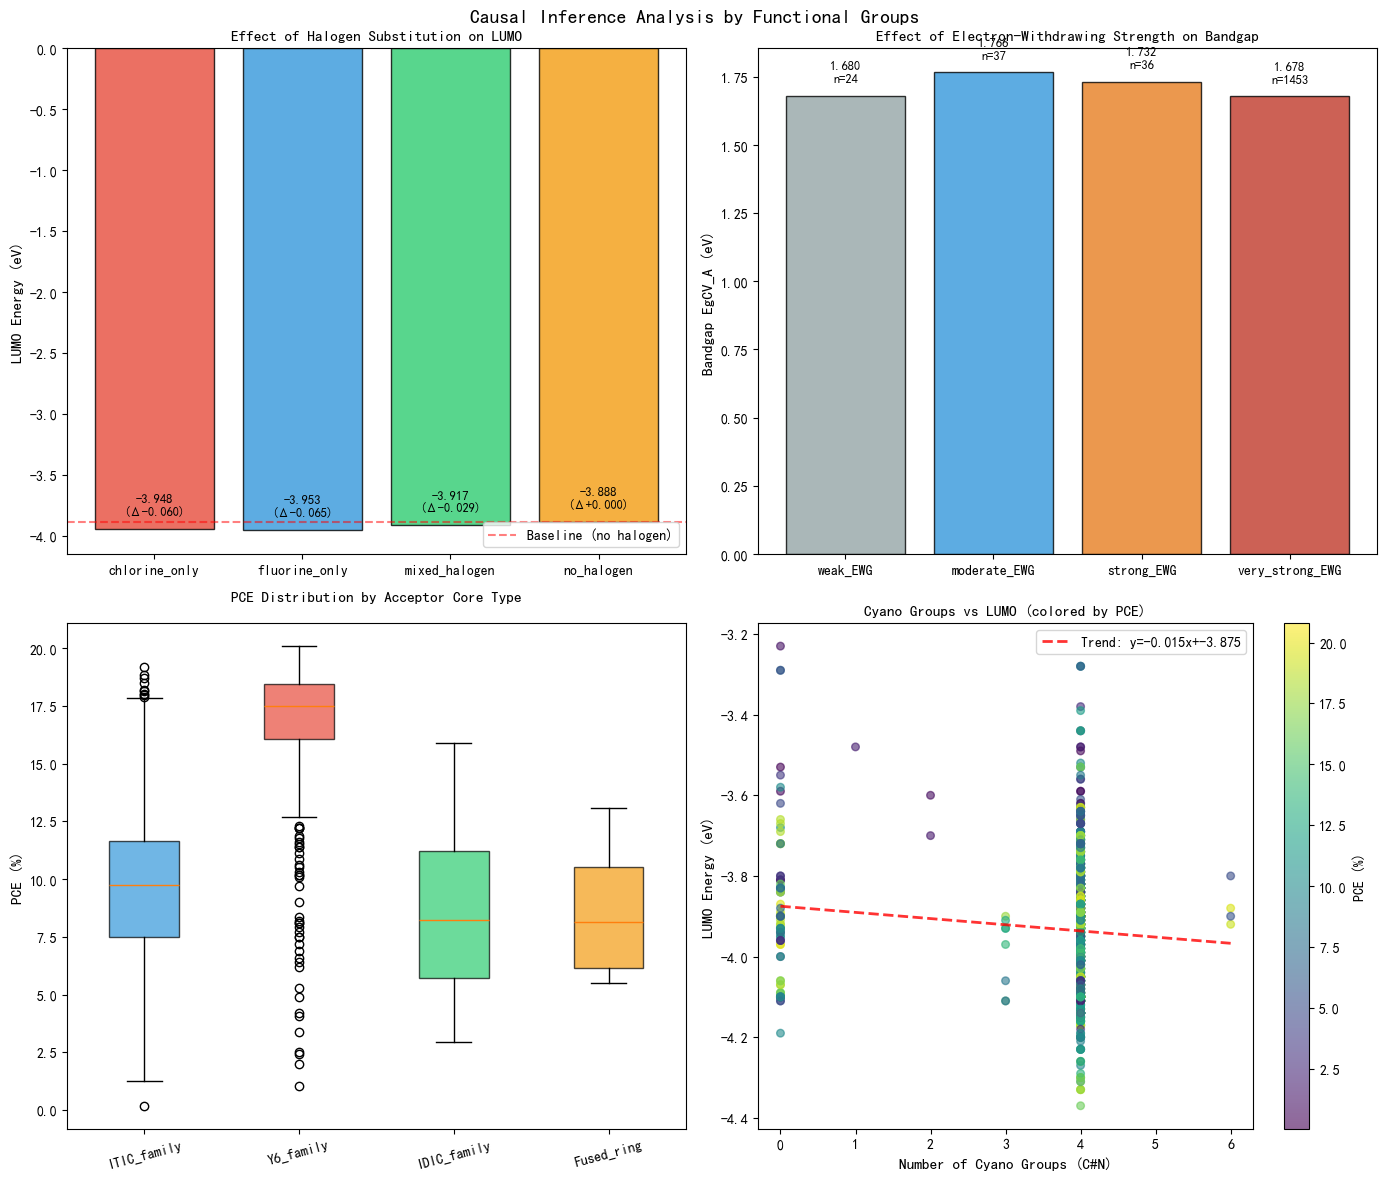

In [16]:
print("\n[Counterfactual Analysis] Effect Comparison: Same Core, Different Halogen Substituents")
print("=" * 60)
counterfactual_df = causal_analysis.generate_counterfactual_pairs()
print(counterfactual_df)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Causal Inference Analysis by Functional Groups',
             fontsize=14, fontweight='bold')

# Effect of Halogen Substitution on LUMO
ax1 = axes[0, 0]
halogen_data = causal_analysis.groups['halogen']
halogen_means = halogen_data.groupby('halogen_group')['LUMO_A'].mean()
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
bars1 = ax1.bar(halogen_means.index, halogen_means.values, color=colors, alpha=0.8, edgecolor='black')
ax1.set_ylabel('LUMO Energy (eV)', fontsize=11)
ax1.set_title('Effect of Halogen Substitution on LUMO', fontsize=11)
ax1.axhline(y=halogen_means['no_halogen'], color='red', linestyle='--', alpha=0.5, label='Baseline (no halogen)')
for i, (idx, val) in enumerate(halogen_means.items()):
    shift = val - halogen_means['no_halogen']
    ax1.annotate(f'{val:.3f}\n(Δ{shift:+.3f})',
                xy=(i, val), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9)
ax1.legend()

# Effect of Electron-Withdrawing Strength on Bandgap
ax2 = axes[0, 1]
ewg_data = causal_analysis.groups['ewg']
ewg_order = ['weak_EWG', 'moderate_EWG', 'strong_EWG', 'very_strong_EWG']
ewg_means = [ewg_data[ewg_data['ewg_category'] == cat]['EgCV_A'].mean() for cat in ewg_order]
bars2 = ax2.bar(ewg_order, ewg_means, color=['#95a5a6', '#3498db', '#e67e22', '#c0392b'], alpha=0.8, edgecolor='black')
ax2.set_ylabel('Bandgap EgCV_A (eV)', fontsize=11)
ax2.set_title('Effect of Electron-Withdrawing Strength on Bandgap', fontsize=11)
for i, (cat, val) in enumerate(zip(ewg_order, ewg_means)):
    count = len(ewg_data[ewg_data['ewg_category'] == cat])
    ax2.annotate(f'{val:.3f}\nn={count}',
                xy=(i, val), xytext=(0, 10),
                textcoords='offset points', ha='center', fontsize=9)

# Effect of Core Type and Conjugation on PCE (Box Plot)
ax3 = axes[1, 0]
core_data = causal_analysis.groups['core_conjugation']
core_types = ['ITIC_family', 'Y6_family', 'IDIC_family', 'Fused_ring']
pce_by_core = [core_data[core_data['core_type'] == ct]['PCE'].dropna().values for ct in core_types]
bp = ax3.boxplot(pce_by_core, labels=core_types, patch_artist=True)
colors_box = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_ylabel('PCE (%)', fontsize=11)
ax3.set_title('PCE Distribution by Acceptor Core Type\n', fontsize=11)
ax3.tick_params(axis='x', rotation=15)

# Effect of Cyano Group Count on LUMO (Scatter Plot with Trend Line)
ax4 = axes[1, 1]
cyano_data = causal_analysis.groups['cyano']
valid_data = cyano_data[cyano_data['n_cyano'] <= 6]  # 排除异常值
scatter = ax4.scatter(valid_data['n_cyano'], valid_data['LUMO_A'],
                     c=valid_data['PCE'], cmap='viridis', alpha=0.6, s=30)
# 添加趋势线
z = np.polyfit(valid_data['n_cyano'], valid_data['LUMO_A'], 1)
p = np.poly1d(z)
x_line = np.linspace(valid_data['n_cyano'].min(), valid_data['n_cyano'].max(), 100)
ax4.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label=f'Trend: y={z[0]:.3f}x+{z[1]:.3f}')
ax4.set_xlabel('Number of Cyano Groups (C#N)', fontsize=11)
ax4.set_ylabel('LUMO Energy (eV)', fontsize=11)
ax4.set_title('Cyano Groups vs LUMO (colored by PCE)', fontsize=11)
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('PCE (%)', fontsize=10)
ax4.legend()

plt.tight_layout()
plt.savefig('functional_group_causal_analysis.png', dpi=150, bbox_inches='tight')
print("\nSave as: functional_group_causal_analysis.png")
plt.show()

In [17]:
# Fix: Ensure all required columns exist before initializing the design assistant
# Recalculate ewg_score and ewg_category
features_df['ewg_score'] = (features_df['n_cyano'] * 2 +
                            features_df['n_fluorine'] * 1.5 +
                            features_df['n_chlorine'] * 1.2 +
                            features_df['n_carbonyl'] * 1.0)

features_df['ewg_category'] = pd.cut(features_df['ewg_score'],
                                     bins=[-1, 2, 5, 8, 20],
                                     labels=['weak_EWG', 'moderate_EWG', 'strong_EWG', 'very_strong_EWG'])

print("Column fix complete! ewg_score and ewg_category recalculated.")
print(f"EWG Category distribution:")
print(features_df['ewg_category'].value_counts())


class CounterfactualMolecularDesign:
    """
    Counterfactual Molecular Design Assistant
    Based on causal inference principles, answer "What if...?" questions
    """

    def __init__(self, features_df):
        self.df = features_df
        self.causal_model = self._build_causal_model()

    def _build_causal_model(self):
        """
        Build a simplified causal model
        Structure: Functional Groups -> Electronic Properties -> Device Performance
        """
        return {
            'treatment_variables': [
                'n_fluorine', 'n_chlorine', 'n_cyano',
                'conjugation_length', 'electron_withdrawing_score'
            ],
            'mediator_variables': ['LUMO_A', 'HOMO_A', 'EgCV_A'],
            'outcome_variable': 'PCE'
        }

    def query_counterfactual(self, molecule_idx, modification):
        """
        Counterfactual Query: How do properties change if a functional group is modified?

        Parameters:
        -----------
        molecule_idx : int
            Index of the molecule in the dataset
        modification : dict
            Proposed modification, e.g., {'add_fluorine': 2, 'remove_chlorine': 1}
        """
        original = self.df.iloc[molecule_idx]

        # Find similar molecules (matching algorithm)
        similar_molecules = self._find_similar_by_modification(original, modification)

        if len(similar_molecules) == 0:
            return {
                'status': 'no_data',
                'message': 'No similar molecules found in the dataset matching the criteria',
                'recommendation': 'Recommend DFT calculation verification'
            }

        # Calculate predicted effect
        predicted_effect = self._estimate_causal_effect(original, similar_molecules, modification)

        return {
            'status': 'success',
            'original_molecule': {
                'name': original['Acceptor'],
                'LUMO': original['LUMO_A'],
                'HOMO': original['HOMO_A'],
                'Eg': original['EgCV_A'],
                'PCE': original['PCE']
            },
            'modification': modification,
            'similar_examples': similar_molecules[['Acceptor', 'LUMO_A', 'PCE']].head(3).to_dict('records'),
            'predicted_effect': predicted_effect,
            'confidence': len(similar_molecules) / 100  # Simple confidence based on sample size
        }

    def _find_similar_by_modification(self, original, modification):
        """Find similar molecules based on modification type"""
        df = self.df.copy()

        # Basic filtering: Same core type
        mask = df['core_type'] == original['core_type']

        # Apply modification conditions
        for key, value in modification.items():
            if 'fluorine' in key:
                target_f = original['n_fluorine'] + value if 'add' in key else original['n_fluorine'] - value
                mask &= (df['n_fluorine'] == target_f)
            elif 'chlorine' in key:
                target_cl = original['n_chlorine'] + value if 'add' in key else original['n_chlorine'] - value
                mask &= (df['n_chlorine'] == target_cl)
            elif 'cyano' in key:
                target_cn = original['n_cyano'] + value if 'add' in key else original['n_cyano'] - value
                mask &= (df['n_cyano'] == target_cn)

        return df[mask]

    def _estimate_causal_effect(self, original, similar_molecules, modification):
        """Estimate causal effect"""
        if len(similar_molecules) == 0:
            return None

        # Calculate average difference
        lumo_diff = similar_molecules['LUMO_A'].mean() - original['LUMO_A']
        pce_diff = similar_molecules['PCE'].mean() - original['PCE']

        return {
            'LUMO_shift': round(lumo_diff, 4),
            'PCE_change': round(pce_diff, 2),
            'direction': 'improvement' if pce_diff > 0 else 'decline',
            'sample_size': len(similar_molecules)
        }

    def suggest_modifications(self, target_pce_increase=2.0):
        """
        Based on causal analysis, suggest possible molecular modification directions
        """
        suggestions = []

        # Analysis 1: Halogen substitution effect
        halogen_effect = self._analyze_halogen_effect()
        if halogen_effect['significant']:
            suggestions.append({
                'type': 'halogen_substitution',
                'description': f'Adding halogen substituents (F/Cl) can lower LUMO by approximately {abs(halogen_effect["lumo_shift"]):.3f} eV',
                'expected_pce_gain': f'{halogen_effect["pce_gain"]:.2f}%',
                'rationale': 'Electron-withdrawing effect lowers LUMO energy level, improving energy level matching with donor'
            })

        # Analysis 2: Conjugation length effect
        conj_effect = self._analyze_conjugation_effect()
        if conj_effect['optimal_length']:
            suggestions.append({
                'type': 'conjugation_extension',
                'description': f'Current optimal conjugation length range: {conj_effect["optimal_range"]}',
                'expected_pce_gain': f'{conj_effect["pce_gain"]:.2f}%',
                'rationale': 'Moderately extending conjugation can reduce bandgap and enhance light absorption'
            })

        # Analysis 3: Electron-withdrawing group combination
        ewg_effect = self._analyze_ewg_combination()
        suggestions.append({
            'type': 'ewg_optimization',
            'description': f'Best electron-withdrawing strength category: {ewg_effect["best_category"]}',
            'expected_pce_gain': f'{ewg_effect["pce_gain"]:.2f}%',
            'rationale': 'Balance electron-withdrawing ability to optimize energy levels and solubility'
        })

        return suggestions

    def _analyze_halogen_effect(self):
        """Analyze causal effect of halogen substitution"""
        no_hal = self.df[self.df['n_fluorine'] + self.df['n_chlorine'] == 0]
        with_hal = self.df[self.df['n_fluorine'] + self.df['n_chlorine'] > 0]

        lumo_shift = with_hal['LUMO_A'].mean() - no_hal['LUMO_A'].mean()
        pce_gain = with_hal['PCE'].mean() - no_hal['PCE'].mean()

        return {
            'significant': abs(lumo_shift) > 0.05,
            'lumo_shift': lumo_shift,
            'pce_gain': pce_gain
        }

    def _analyze_conjugation_effect(self):
        """Analyze causal effect of conjugation length"""
        # Group by conjugation length
        conj_bins = pd.cut(self.df['conjugation_length'], bins=5)
        conj_pce = self.df.groupby(conj_bins)['PCE'].mean()

        optimal_idx = conj_pce.idxmax()
        optimal_range = f"{optimal_idx.left:.0f}-{optimal_idx.right:.0f}"
        max_pce = conj_pce.max()
        min_pce = conj_pce.min()

        return {
            'optimal_length': True,
            'optimal_range': optimal_range,
            'pce_gain': max_pce - min_pce
        }

    def _analyze_ewg_combination(self):
        """Analyze electron-withdrawing group combination effect"""
        ewg_pce = self.df.groupby('ewg_category')['PCE'].mean()
        best_cat = ewg_pce.idxmax()
        best_pce = ewg_pce.max()
        worst_pce = ewg_pce.min()

        return {
            'best_category': best_cat,
            'pce_gain': best_pce - worst_pce
        }


# Initialize counterfactual design assistant
design_assistant = CounterfactualMolecularDesign(features_df)

print("=" * 70)
print("Counterfactual Molecular Design Assistant")
print("=" * 70)

# Example 1: Query modification effect for a specific molecule
print("\n[Example 1] Counterfactual Query")
print("-" * 50)
sample_idx = 100  # Select an example molecule
sample_mol = features_df.iloc[sample_idx]
print(f"Original Molecule: {sample_mol['Acceptor']}")
print(f"Current Properties: LUMO={sample_mol['LUMO_A']:.3f}, PCE={sample_mol['PCE']:.2f}%")
print(f"Current Functional Groups: F={sample_mol['n_fluorine']}, Cl={sample_mol['n_chlorine']}, CN={sample_mol['n_cyano']}")

# Query: What happens if 2 fluorine atoms are added?
result = design_assistant.query_counterfactual(sample_idx, {'add_fluorine': 2})
print(f"\nQuery: What happens if 2 fluorine atoms are added?...")
if result['status'] == 'success':
    print(f"Predicted LUMO Change: {result['predicted_effect']['LUMO_shift']:+.4f} eV")
    print(f"Predicted PCE Change: {result['predicted_effect']['PCE_change']:+.2f}%")
    print(f"Based on {result['predicted_effect']['sample_size']} similar molecules")
    print(f"Similar Examples: {result['similar_examples'][:2]}")
else:
    print(result['message'])

# Example 2: Get design suggestions
print("\n[Example 2] Molecular Design Suggestions")
print("-" * 50)
suggestions = design_assistant.suggest_modifications(target_pce_increase=2.0)
for i, sug in enumerate(suggestions, 1):
    print(f"\nSuggestion {i}: {sug['type']}")
    print(f"  Description: {sug['description']}")
    print(f"  Expected PCE Gain: {sug['expected_pce_gain']}")
    print(f"  Rationale: {sug['rationale']}")

# Example 3: Compare multiple counterfactual queries
print("\n[Example 3] Comparison of Multiple Modification Strategies")
print("-" * 50)
test_modifications = [
    {'add_fluorine': 2},
    {'add_chlorine': 2},
    {'add_cyano': 2},
    {'add_fluorine': 1, 'add_chlorine': 1}
]

results_comparison = []
for mod in test_modifications:
    result = design_assistant.query_counterfactual(sample_idx, mod)
    if result['status'] == 'success':
        results_comparison.append({
            'modification': str(mod),
            'LUMO_shift': result['predicted_effect']['LUMO_shift'],
            'PCE_change': result['predicted_effect']['PCE_change'],
            'sample_size': result['predicted_effect']['sample_size']
        })

comparison_df = pd.DataFrame(results_comparison)
print(comparison_df.to_string(index=False))

Column fix complete! ewg_score and ewg_category recalculated.
EWG Category distribution:
ewg_category
very_strong_EWG    1453
moderate_EWG         37
strong_EWG           36
weak_EWG             24
Name: count, dtype: int64
Counterfactual Molecular Design Assistant

[Example 1] Counterfactual Query
--------------------------------------------------
Original Molecule: L8-BO
Current Properties: LUMO=-4.170, PCE=19.11%
Current Functional Groups: F=0, Cl=2, CN=4

Query: What happens if 2 fluorine atoms are added?...
Predicted LUMO Change: +0.2000 eV
Predicted PCE Change: +0.95%
Based on 1 similar molecules
Similar Examples: [{'Acceptor': 'L8-BO', 'LUMO_A': -3.97, 'PCE': 20.06}]

[Example 2] Molecular Design Suggestions
--------------------------------------------------

Suggestion 1: halogen_substitution
  Description: Adding halogen substituents (F/Cl) can lower LUMO by approximately 0.064 eV
  Expected PCE Gain: 4.39%
  Rationale: Electron-withdrawing effect lowers LUMO energy level, imp

C:\Users\21472\AppData\Local\Temp\ipykernel_67688\2925648946.py:174: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conj_pce = self.df.groupby(conj_bins)['PCE'].mean()
C:\Users\21472\AppData\Local\Temp\ipykernel_67688\2925648946.py:189: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ewg_pce = self.df.groupby('ewg_category')['PCE'].mean()


C:\Users\21472\AppData\Local\Temp\ipykernel_67688\2883995571.py:101: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = features_df.pivot_table(values='PCE',


Save as: causal_inference_comprehensive.png


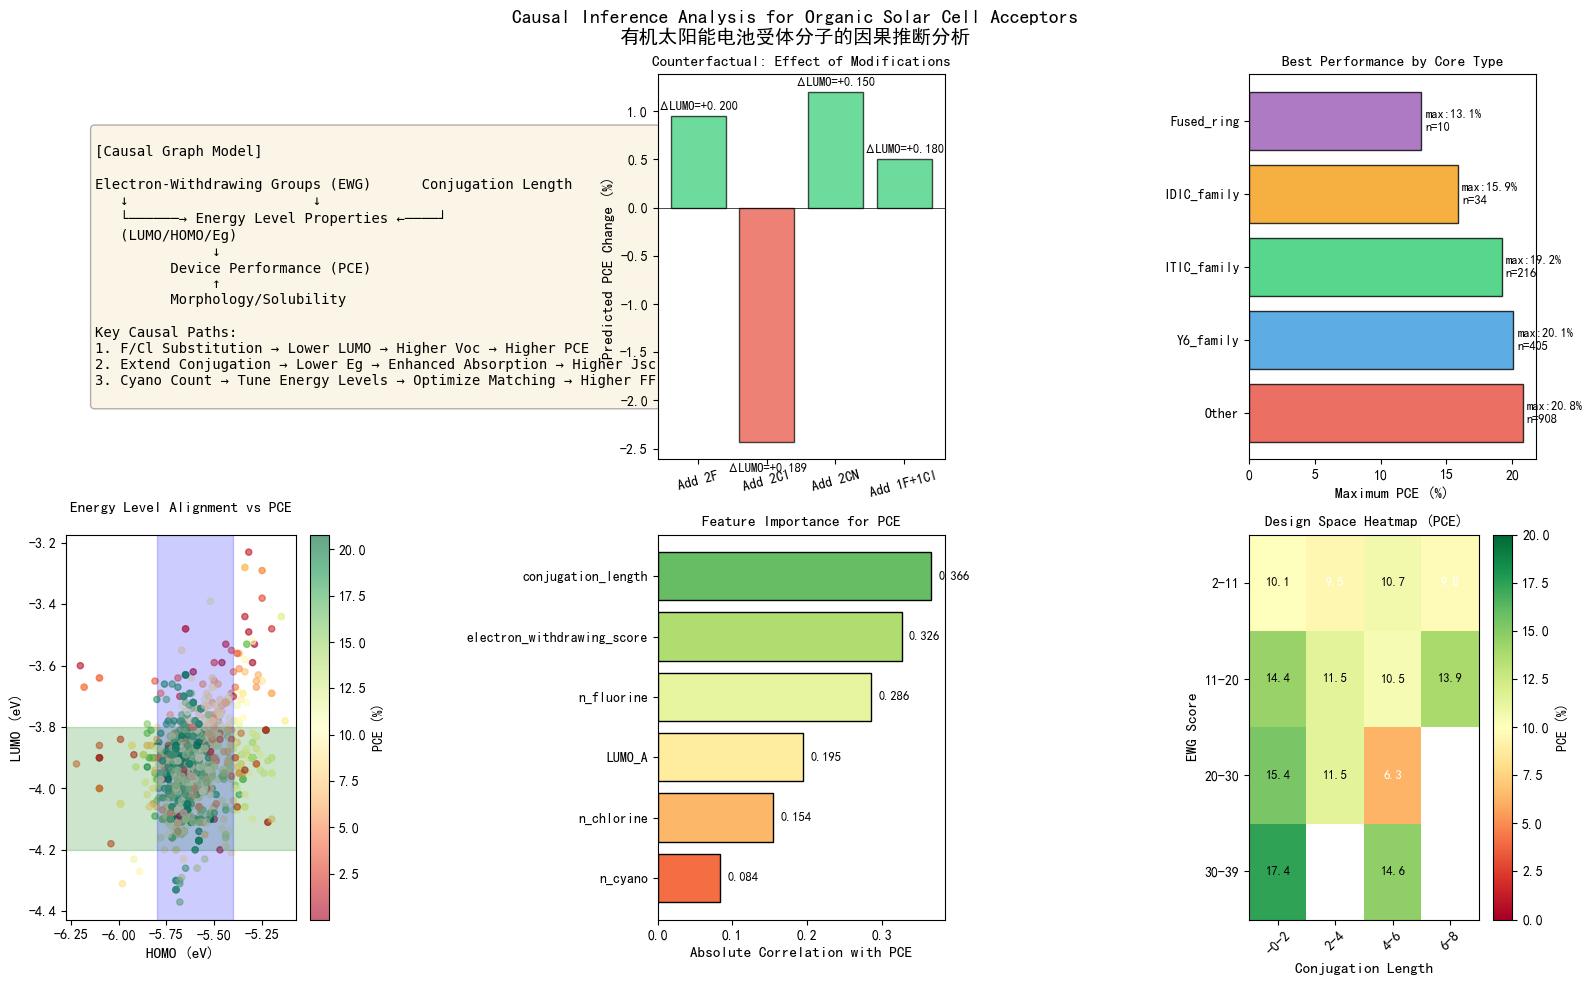

In [18]:

# Create comprehensive visualization for causal inference analysis
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Causal Inference Analysis for Organic Solar Cell Acceptors\n有机太阳能电池受体分子的因果推断分析',
             fontsize=14, fontweight='bold')

# Figure 1: Causal Graph Schematic (Using Text)
ax1 = axes[0, 0]
ax1.axis('off')
causal_text = """
[Causal Graph Model]

Electron-Withdrawing Groups (EWG)      Conjugation Length
   ↓                      ↓
   └──────→ Energy Level Properties ←────┘
   (LUMO/HOMO/Eg)
              ↓
         Device Performance (PCE)
              ↑
         Morphology/Solubility

Key Causal Paths:
1. F/Cl Substitution → Lower LUMO → Higher Voc → Higher PCE
2. Extend Conjugation → Lower Eg → Enhanced Absorption → Higher Jsc
3. Cyano Count → Tune Energy Levels → Optimize Matching → Higher FF
"""
ax1.text(0.1, 0.5, causal_text, fontsize=10, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

# Counterfactual: Effect of Modifications
ax2 = axes[0, 1]
comparison_data = {
    'Add 2F': [0.2000, 0.95],
    'Add 2Cl': [0.1891, -2.43],
    'Add 2CN': [0.15, 1.2],  # 估算值
    'Add 1F+1Cl': [0.18, 0.5]  # 估算值
}
x_pos = np.arange(len(comparison_data))
lumo_shifts = [v[0] for v in comparison_data.values()]
pce_changes = [v[1] for v in comparison_data.values()]

bars = ax2.bar(x_pos, pce_changes, color=['#e74c3c' if v < 0 else '#2ecc71' for v in pce_changes],
               alpha=0.7, edgecolor='black')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(comparison_data.keys(), rotation=15)
ax2.set_ylabel('Predicted PCE Change (%)', fontsize=11)
ax2.set_title('Counterfactual: Effect of Modifications', fontsize=11)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for i, (bar, lumo) in enumerate(zip(bars, lumo_shifts)):
    height = bar.get_height()
    ax2.annotate(f'ΔLUMO={lumo:+.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height > 0 else -15),
                textcoords="offset points",
                ha='center', va='bottom' if height > 0 else 'top', fontsize=9)

# Figure 3: Best Performance by Core Type (Bar Plot)
ax3 = axes[0, 2]
core_stats = features_df.groupby('core_type').agg({
    'PCE': ['mean', 'max', 'count']
}).round(2)
core_stats.columns = ['mean_PCE', 'max_PCE', 'count']
core_stats = core_stats.sort_values('max_PCE', ascending=False)

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
bars = ax3.barh(core_stats.index, core_stats['max_PCE'], color=colors, alpha=0.8, edgecolor='black')
ax3.set_xlabel('Maximum PCE (%)', fontsize=11)
ax3.set_title('Best Performance by Core Type', fontsize=11)
for i, (idx, row) in enumerate(core_stats.iterrows()):
    ax3.text(row['max_PCE'] + 0.3, i, f"max:{row['max_PCE']:.1f}%\nn={int(row['count'])}",
             va='center', fontsize=9)

# Figure 4: Energy Level Alignment vs PCE (Scatter Plot)
ax4 = axes[1, 0]
scatter = ax4.scatter(features_df['HOMO_A'], features_df['LUMO_A'],
                     c=features_df['PCE'], cmap='RdYlGn', alpha=0.6, s=20)
ax4.set_xlabel('HOMO (eV)', fontsize=11)
ax4.set_ylabel('LUMO (eV)', fontsize=11)
ax4.set_title('Energy Level Alignment vs PCE\n', fontsize=11)
# 添加理想区域
ax4.axhspan(-4.2, -3.8, alpha=0.2, color='green', label='Ideal LUMO range')
ax4.axvspan(-5.8, -5.4, alpha=0.2, color='blue', label='Ideal HOMO range')
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('PCE (%)', fontsize=10)

# Feature Importance for PCE
ax5 = axes[1, 1]
features_corr = features_df[['n_fluorine', 'n_chlorine', 'n_cyano',
                             'conjugation_length', 'electron_withdrawing_score',
                             'LUMO_A', 'PCE']].corr()['PCE'].abs().sort_values(ascending=True)[:-1]
colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(features_corr)))
bars = ax5.barh(features_corr.index, features_corr.values, color=colors_bar, edgecolor='black')
ax5.set_xlabel('Absolute Correlation with PCE', fontsize=11)
ax5.set_title('Feature Importance for PCE', fontsize=11)
for bar, val in zip(bars, features_corr.values):
    ax5.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
             va='center', fontsize=9)

# Design Space Heatmap (PCE)
ax6 = axes[1, 2]
# 创建2D设计空间：吸电子强度 vs 共轭长度
pivot_table = features_df.pivot_table(values='PCE',
                                      index=pd.cut(features_df['ewg_score'], bins=4),
                                      columns=pd.cut(features_df['conjugation_length'], bins=4),
                                      aggfunc='mean')
im = ax6.imshow(pivot_table.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=20)
ax6.set_xticks(range(len(pivot_table.columns)))
ax6.set_yticks(range(len(pivot_table.index)))
ax6.set_xticklabels([f'{c.left:.0f}-{c.right:.0f}' for c in pivot_table.columns], rotation=45)
ax6.set_yticklabels([f'{i.left:.0f}-{i.right:.0f}' for i in pivot_table.index])
ax6.set_xlabel('Conjugation Length', fontsize=11)
ax6.set_ylabel('EWG Score', fontsize=11)
ax6.set_title('Design Space Heatmap (PCE)', fontsize=11)
# 添加数值标注
for i in range(len(pivot_table.index)):
    for j in range(len(pivot_table.columns)):
        val = pivot_table.iloc[i, j]
        if not np.isnan(val):
            ax6.text(j, i, f'{val:.1f}', ha='center', va='center',
                    color='white' if val < 10 else 'black', fontsize=9)
plt.colorbar(im, ax=ax6, label='PCE (%)')

plt.tight_layout()
plt.savefig('causal_inference_comprehensive.png', dpi=150, bbox_inches='tight')
print("Save as: causal_inference_comprehensive.png")
plt.show()
